# Perbandingan Spatial Jitter: Versi Baseline vs Versi Local

Membuktikan bahwa **urutan jitter terhadap normalisasi** menghasilkan efek yang sangat berbeda.

- **Versi Baseline** (VIPL-SLP): Jitter pada koordinat mentah [0, ~1] → baru dinormalisasi
- **Versi Local** (pipeline temanmu): Normalisasi dulu (translate+scale bone-length) → baru jitter

Masing-masing versi ditampilkan sebagai grid **2x5** untuk `sigma = 0.001, 0.002, ..., 0.01`
Visualisasi menggunakan **tangan kanan** (keypoint 21-41), skala konsisten di semua subplot.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

plt.style.use('default')
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'font.size'        : 9,
    'axes.titlesize'   : 9,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

STD_VALUES   = [round(i * 0.01, 3) for i in range(1, 11)]  # 0.001 ... 0.01
TARGET_FRAME = 35

# MediaPipe hand skeleton connections (local index 0-20)
HAND_CONNS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17)
]

# Fixed axis limits dari data aktual frame 35 + padding
# Raw space : right hand x=[0.4444,0.5217], y=[0.3269,0.5269]
RAW_XLIM  = (0.39, 0.58)
RAW_YLIM  = (0.24, 0.61)

# Normalized space : x=[-0.08,0.85], y=[-2.41,0.00]
NORM_XLIM = (-0.55, 1.20)
NORM_YLIM = (-2.85, 0.45)

print('std_dev values:', STD_VALUES)

std_dev values: [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]


In [2]:
with open('../data/pickle/pose_bisindo.pkl', 'rb') as f:
    dataset = pickle.load(f)

SELECTED_ID = 'P1_S15_R1'
assert SELECTED_ID in dataset, f'{SELECTED_ID} nggak ada. Sample key: {list(dataset.keys())[:5]}'

kp_data   = dataset[SELECTED_ID]['keypoints']  # (T, 86, 2)
assert TARGET_FRAME < len(kp_data), f'Frame {TARGET_FRAME} > panjang video ({len(kp_data)})'

orig_full = kp_data[TARGET_FRAME].copy()        # (86, 2)
orig_rh   = orig_full[21:42].copy()             # tangan kanan, index lokal 0-20

def bbox_limits(pts, pad):
    v = pts[pts[:, 0] != 0]
    (xmin, ymin), (xmax, ymax) = v.min(0), v.max(0)
    return (xmin - pad, xmax + pad), (ymin - pad, ymax + pad)

# pad 0.05 cukup buat nutupin sebaran jitter (~3*sigma = 0.03 di sigma 0.01)
RAW_XLIM, RAW_YLIM = bbox_limits(orig_rh, pad=0.05)
print('RAW_XLIM:', RAW_XLIM, '| RAW_YLIM:', RAW_YLIM)

print(f'Video   : {SELECTED_ID}  |  Shape: {kp_data.shape}')
print(f'Frame   : {TARGET_FRAME}')
print(f'RH x    : [{orig_rh[:,0].min():.4f}, {orig_rh[:,0].max():.4f}]')
print(f'RH y    : [{orig_rh[:,1].min():.4f}, {orig_rh[:,1].max():.4f}]')

RAW_XLIM: (0.26165632605552674, 0.5180813252925873) | RAW_YLIM: (0.2204528570175171, 0.6316787481307984)
Video   : P1_S15_R1  |  Shape: (115, 86, 2)
Frame   : 35
RH x    : [0.3117, 0.4681]
RH y    : [0.2705, 0.5817]


In [28]:
LANDMARK_NAMES = {
    0: "Wrist",
    5: "Index MCP",
    12: "Middle Tip",
}

def apply_jitter(points, std_dev, frame=None):
    """
    Gaussian noise hanya pada keypoint valid.
    """

    noise = np.random.normal(
        loc=0,
        scale=std_dev,
        size=points.shape
    )

    mask = (points != 0)

    result = points.copy()
    result[mask] += noise[mask]

    print("\n" + "=" * 105)
    print(f"Spatial Jitter (σ = {std_dev:.3f})")
    print("=" * 105)

    header = (
        f"{'Frame':<8}"
        f"{'Landmark':<15}"
        f"{'Koordinat Awal':<24}"
        f"{'Gaussian Noise (Δx, Δy)':<30}"
        f"{'Koordinat Setelah Jitter'}"
    )

    print(header)
    print("-" * 105)

    for idx, name in LANDMARK_NAMES.items():

        frame_text = "-" if frame is None else str(frame)

        print(
            f"{frame_text:<8}",
            f"{name:<15}",
            f"({points[idx,0]:.4f}; {points[idx,1]:.4f})".ljust(24),
            f"({noise[idx,0]:+0.4f}; {noise[idx,1]:+0.4f})".ljust(30),
            f"({result[idx,0]:.4f}; {result[idx,1]:.4f})"
        )

    print("=" * 105)

    return result


def normalize_hand(points_21, wrist_idx=0, mcp_idx=9):
    """
    Normalisasi tangan (versi local):
      1. Translate: kurangi posisi wrist
      2. Scale    : bagi jarak wrist->middle_MCP
    Output dalam satuan bone-length.
    
    Return: (normalized_points, scale, valid_per_kp)
    valid_per_kp: boolean array (21,) — True jika keypoint valid di raw space
    """
    valid_mask = (points_21 != 0)  # Shape: (21, 2)
    valid_per_kp = np.any(valid_mask, axis=1)  # Shape: (21,) — True jika x OR y != 0
    
    wrist = points_21[wrist_idx].copy()
    mcp   = points_21[mcp_idx].copy()
    scale = np.linalg.norm(mcp - wrist)
    scale = max(scale, 1e-6)
    return (points_21 - wrist) / scale, scale, valid_per_kp


def _draw_hand(ax, pts, color, valid_per_kp=None):
    """Draw dengan respek ke valid_per_kp (khusus untuk normalized space)."""
    for p1, p2 in HAND_CONNS:
        # Jika ada valid_per_kp (normalized space), pakai itu; kalau tidak, check value
        if valid_per_kp is not None:
            if not (valid_per_kp[p1] and valid_per_kp[p2]):
                continue
        else:
            # Raw space: check apakah kedua endpoint coordinate-nya != 0
            if pts[p1,0] == 0 or pts[p2,0] == 0:
                continue
        
        ax.plot(
            [pts[p1,0], pts[p2,0]],
            [pts[p1,1], pts[p2,1]],
            color='#4169E1', alpha=0.45, lw=0.8, zorder=1
        )
    
    # Scatter points
    if valid_per_kp is not None:
        valid = valid_per_kp  # Gunakan mask dari raw space
    else:
        valid = pts[:,0] != 0  # Raw space: hanya check x != 0
    
    ax.scatter(
        pts[valid,0], pts[valid,1],
        c=color, s=18, edgecolors='black', linewidths=0.4, zorder=3
    )


def _style_ax(ax, title, xlim, ylim):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#F8F8F8')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


def plot_raw(ax, rh_21, title, color):
    _draw_hand(ax, rh_21, color, valid_per_kp=None)
    _style_ax(ax, title, RAW_XLIM, RAW_YLIM)


def plot_norm(ax, rh_norm_21, title, color, valid_per_kp):
    _draw_hand(ax, rh_norm_21, color, valid_per_kp=valid_per_kp)
    _style_ax(ax, title, NORM_XLIM, NORM_YLIM)


# Pre-compute normalized right hand
orig_rh_norm, bone_scale, rh_valid_per_kp = normalize_hand(orig_rh)
NORM_XLIM, NORM_YLIM = bbox_limits(orig_rh_norm, pad=0.30)  # satuan bone-length, jadi pad lebih gede
print(f'Bone length (wrist->MCP) : {bone_scale:.5f} raw units')
print(f'sigma=0.01 di raw space  : {0.01:.5f} raw units')
print(f'sigma=0.01 di norm space : {0.01 * bone_scale:.6f} raw units  ({0.01/bone_scale*100:.1f}% bone)')

Bone length (wrist->MCP) : 0.15293 raw units
sigma=0.01 di raw space  : 0.01000 raw units
sigma=0.01 di norm space : 0.001529 raw units  (6.5% bone)


---
## Versi Baseline - Jitter pada Raw Space [0, ~1]

Urutan: `raw coords [0,~1]  ->  Jitter(sigma)  ->  normalize`

Ditampilkan: tangan kanan **setelah jitter, sebelum normalisasi**.  
Semua subplot dikunci pada skala yang sama.

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_20836\151527876.py:54: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


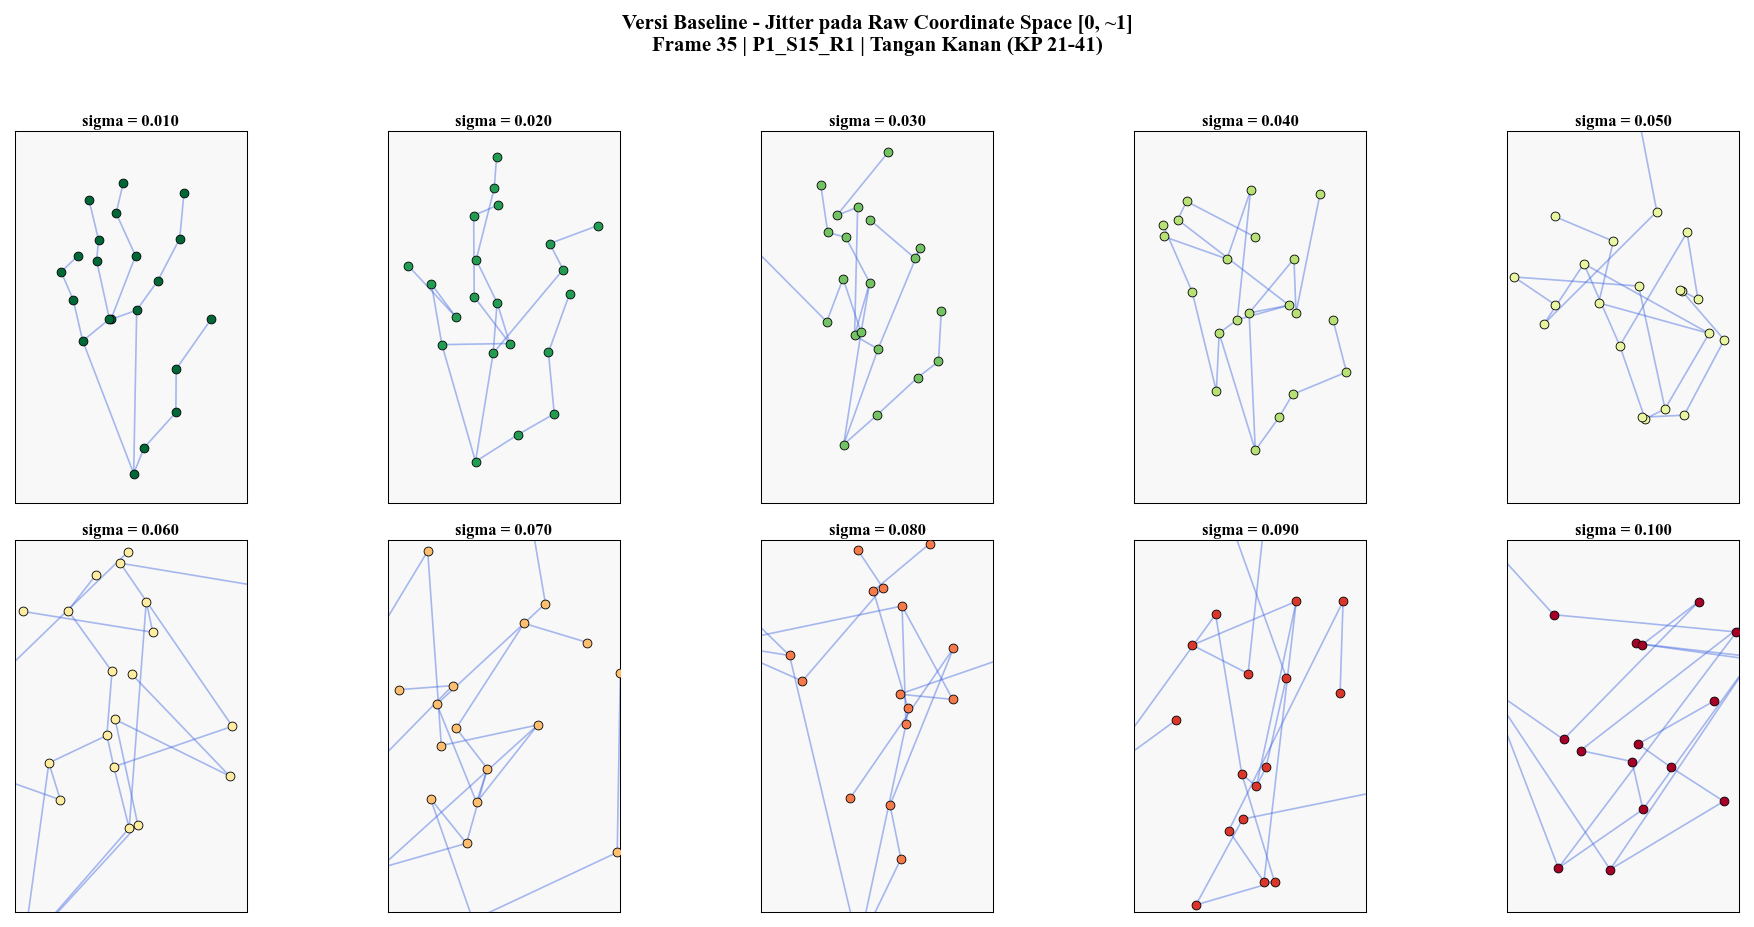

Saved: docs/jitter_versi_baseline.png


In [5]:
colors = [plt.cm.RdYlGn_r(i / (len(STD_VALUES) - 1)) for i in range(len(STD_VALUES))]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, (std, color) in enumerate(zip(STD_VALUES, colors)):
    rh_jit = apply_jitter(orig_rh, std_dev=std)
    plot_raw(axes[i], rh_jit, title=f'sigma = {std:.3f}', color=color)

fig.suptitle(
    f'Versi Baseline - Jitter pada Raw Coordinate Space [0, ~1]\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21-41)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/jitter_versi_baseline.png', bbox_inches='tight')
plt.show()
print('Saved: docs/jitter_versi_baseline.png')

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_20836\151527876.py:54: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


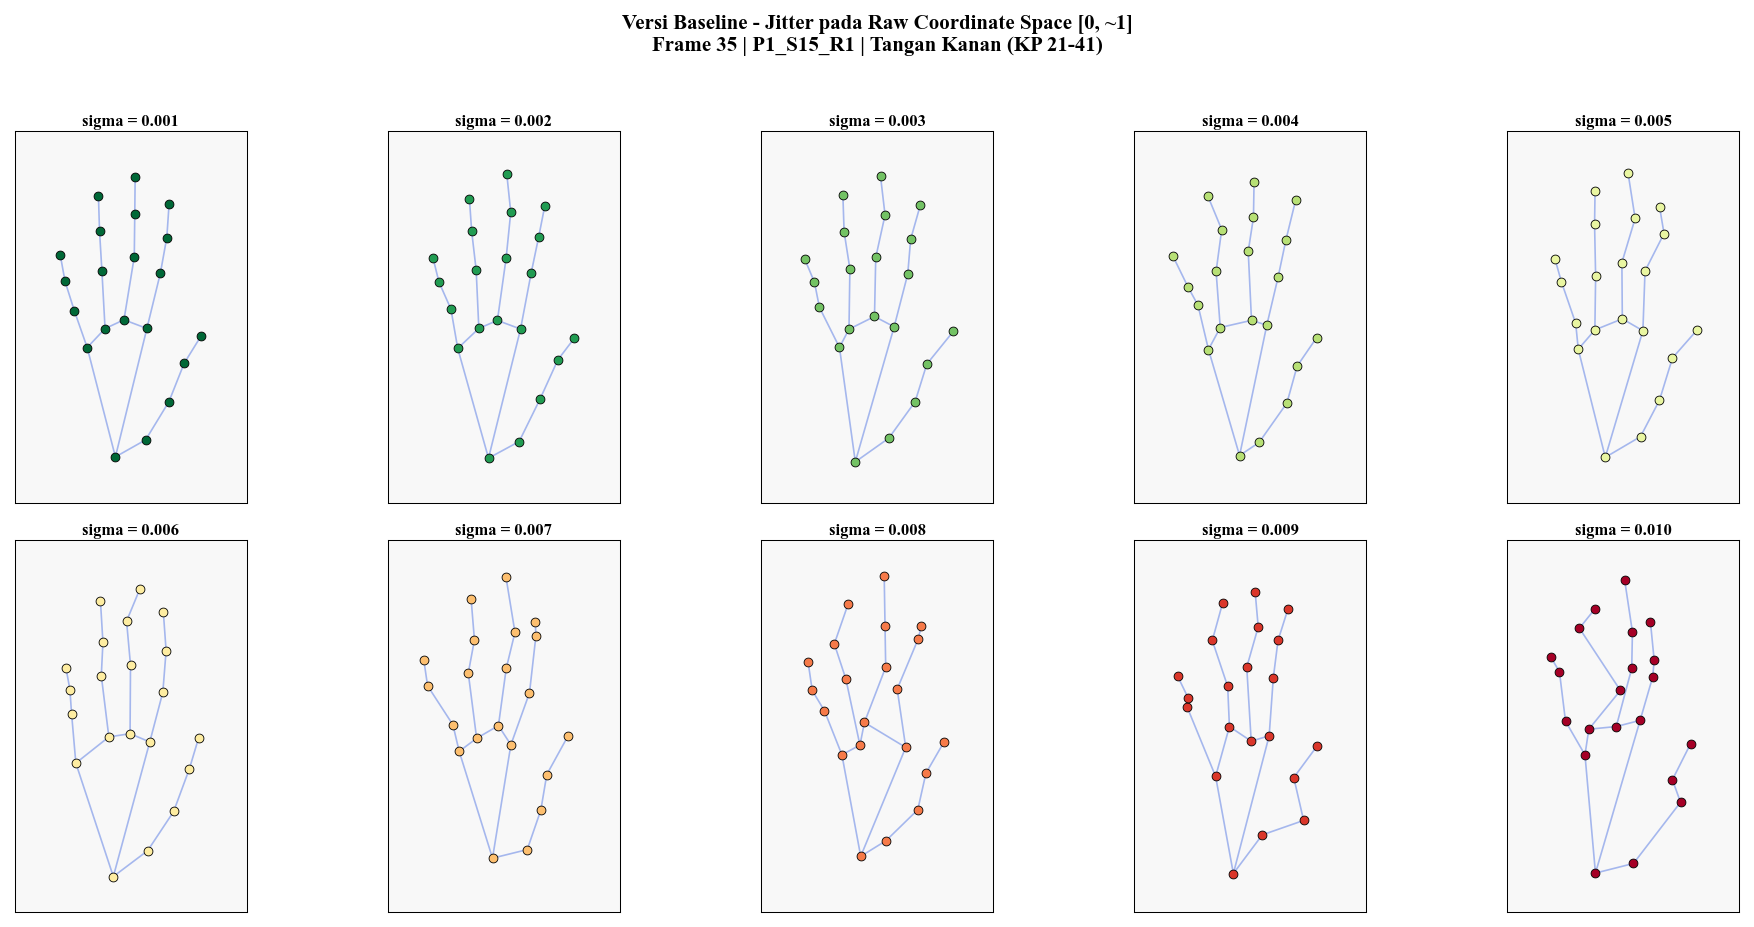

Saved: docs/jitter_versi_baseline.png


In [9]:
STD_VALUES   = [round(i * 0.001, 3) for i in range(1, 11)]  # 0.001 ... 0.01
colors = [plt.cm.RdYlGn_r(i / (len(STD_VALUES) - 1)) for i in range(len(STD_VALUES))]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, (std, color) in enumerate(zip(STD_VALUES, colors)):
    rh_jit = apply_jitter(orig_rh, std_dev=std)
    plot_raw(axes[i], rh_jit, title=f'sigma = {std:.3f}', color=color)

fig.suptitle(
    f'Versi Baseline - Jitter pada Raw Coordinate Space [0, ~1]\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21-41)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/jitter_versi_baseline.png', bbox_inches='tight')
plt.show()
print('Saved: docs/jitter_versi_baseline.png')

---
## Versi Local - Normalize Dulu, Baru Jitter

Urutan: `raw coords  ->  translate(wrist) + scale(bone)  ->  Jitter(sigma)`

Ditampilkan: tangan kanan dalam **bone-length units** setelah normalisasi + jitter.  
Wrist berada di origin (0,0), jarak wrist->MCP = 1 bone-length.  
Semua subplot dikunci pada skala yang sama.

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_20836\151527876.py:54: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


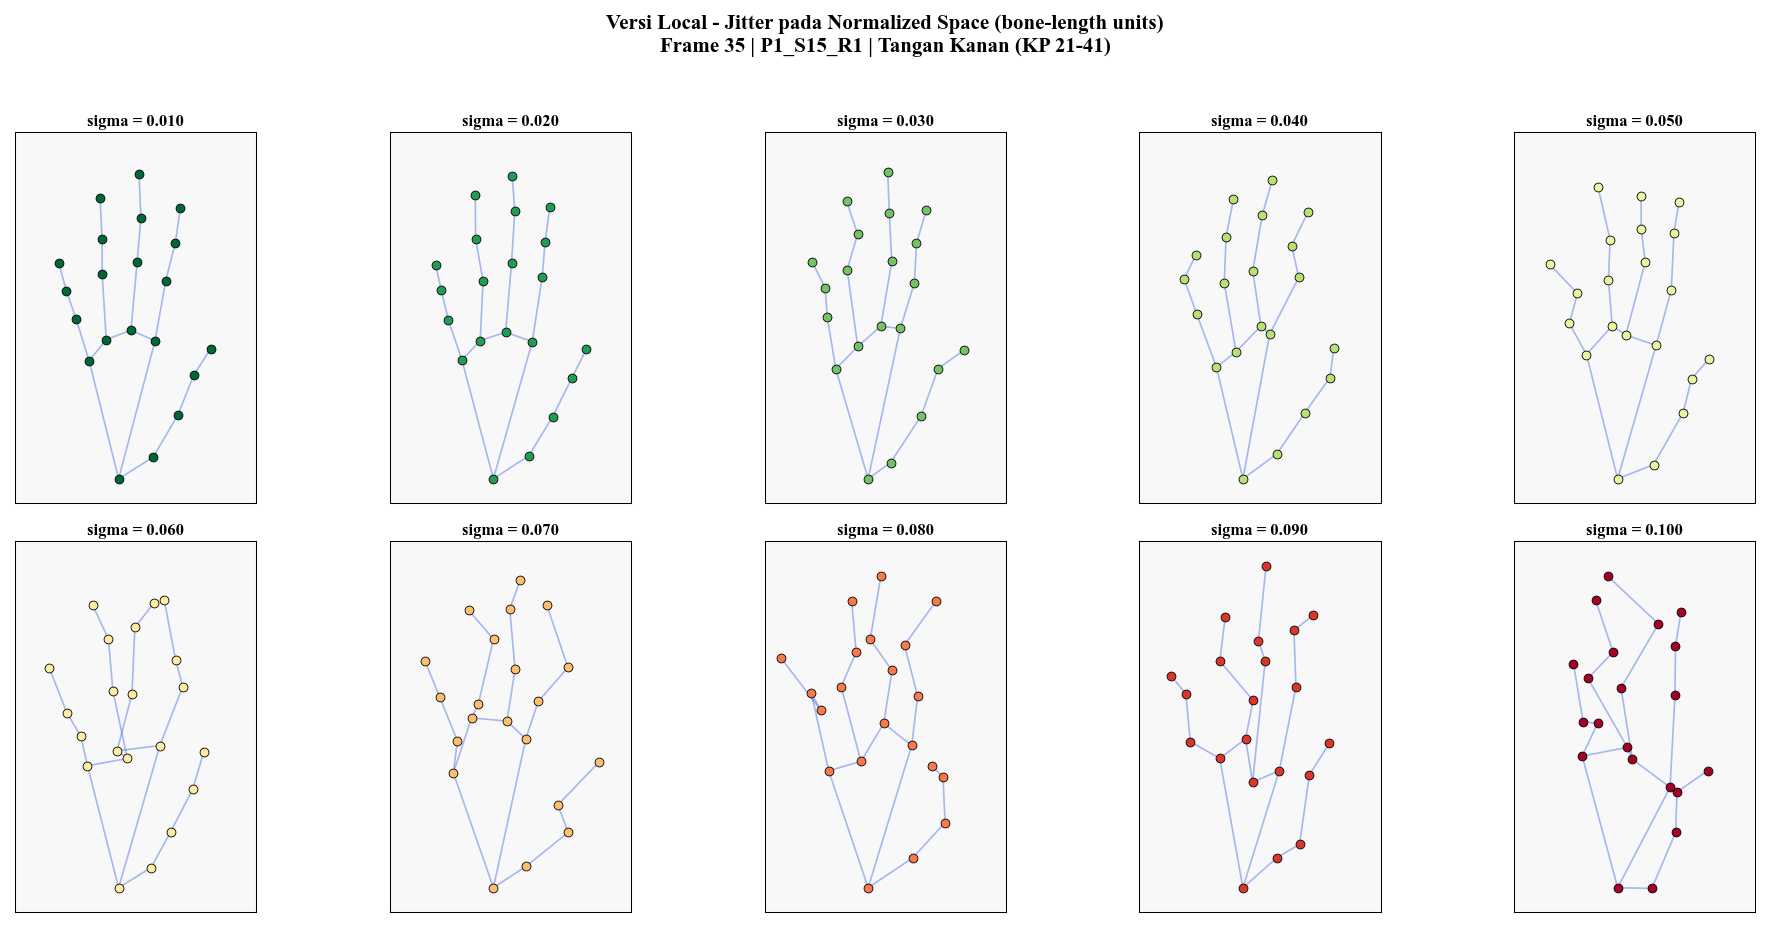

Saved: docs/jitter_versi_local.png


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, (std, color) in enumerate(zip(STD_VALUES, colors)):
    rh_norm_jit = apply_jitter(orig_rh_norm, std_dev=std)
    plot_norm(axes[i], rh_norm_jit, title=f'sigma = {std:.3f}', color=color, valid_per_kp=rh_valid_per_kp)

fig.suptitle(
    f'Versi Local - Jitter pada Normalized Space (bone-length units)\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21-41)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/jitter_versi_local.png', bbox_inches='tight')
plt.show()
print('Saved: docs/jitter_versi_local.png')

C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_20836\151527876.py:54: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


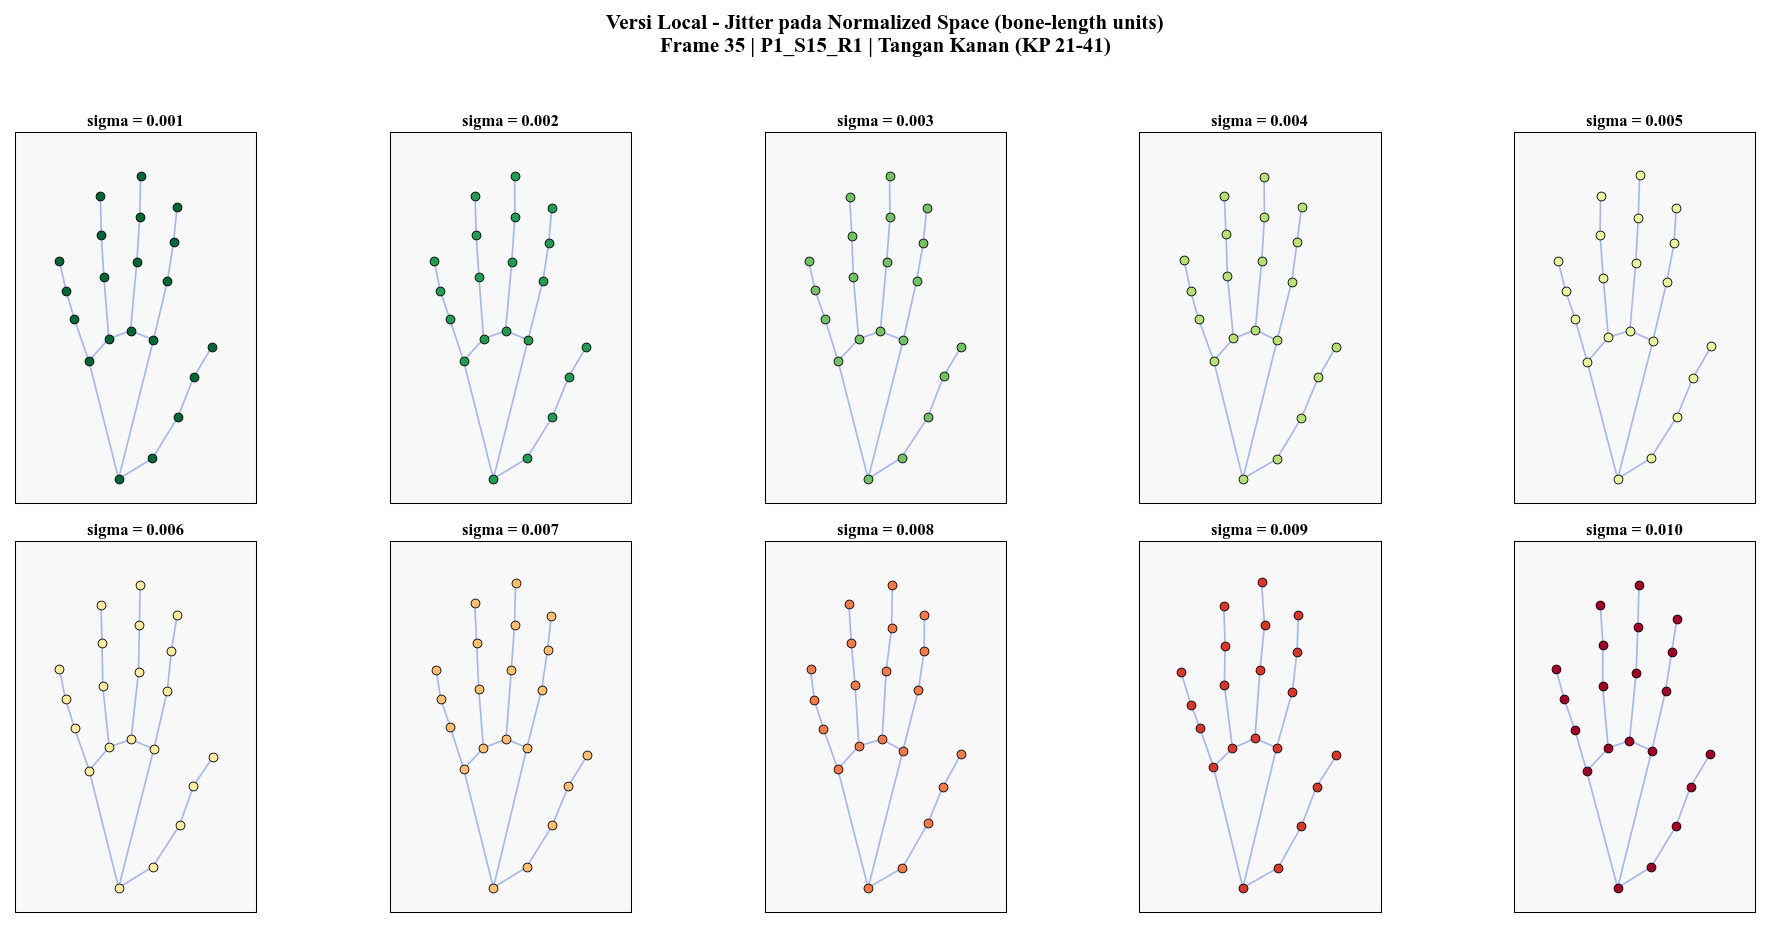

Saved: docs/jitter_versi_local.png


In [10]:
STD_VALUES   = [round(i * 0.001, 3) for i in range(1, 11)]  # 0.001 ... 0.01
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.flatten()

for i, (std, color) in enumerate(zip(STD_VALUES, colors)):
    rh_norm_jit = apply_jitter(orig_rh_norm, std_dev=std)
    plot_norm(axes[i], rh_norm_jit, title=f'sigma = {std:.3f}', color=color, valid_per_kp=rh_valid_per_kp)

fig.suptitle(
    f'Versi Local - Jitter pada Normalized Space (bone-length units)\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21-41)',
    fontsize=10, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('docs/jitter_versi_local.png', bbox_inches='tight')
plt.show()
print('Saved: docs/jitter_versi_local.png')

### Visualisas Baseline vs Spatial Jitter


Spatial Jitter (σ = 0.006)
Frame   Landmark       Koordinat Awal          Gaussian Noise (Δx, Δy)       Koordinat Setelah Jitter
---------------------------------------------------------------------------------------------------------
35       Wrist           (0.3724; 0.5817)         (-0.0009; -0.0020)             (0.3715; 0.5797)
35       Index MCP       (0.4082; 0.4388)         (+0.0035; -0.0025)             (0.4117; 0.4363)
35       Middle Tip      (0.3946; 0.2705)         (-0.0054; +0.0031)             (0.3893; 0.2735)

Spatial Jitter (σ = 0.006)
Frame   Landmark       Koordinat Awal          Gaussian Noise (Δx, Δy)       Koordinat Setelah Jitter
---------------------------------------------------------------------------------------------------------
35       Wrist           (0.3724; 0.5817)         (-0.0003; +0.0011)             (0.3721; 0.5828)
35       Index MCP       (0.4082; 0.4388)         (+0.0062; -0.0085)             (0.4144; 0.4303)
35       Middle Tip      (0.3946; 0.27

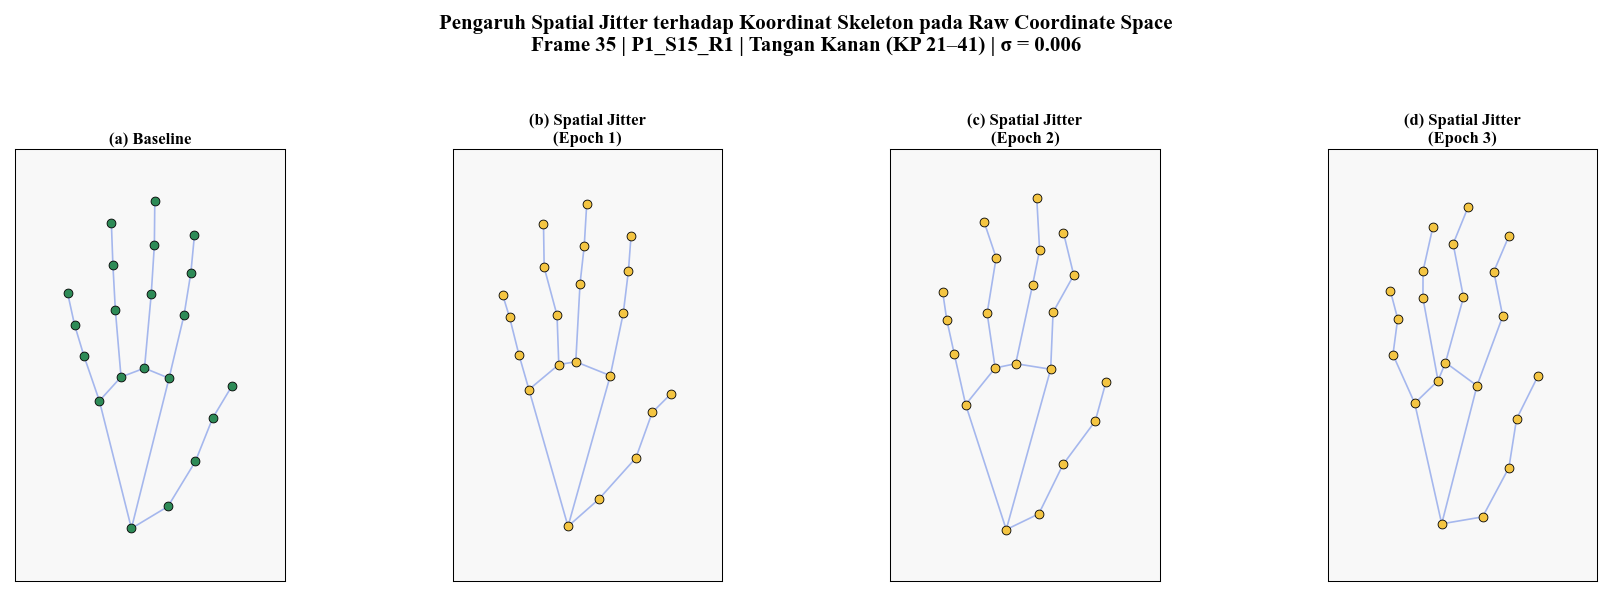

Saved: docs/perbandingan_baseline_vs_spatial_jitter_raw.png


In [29]:
STD = 0.006

# Tiga realisasi Spatial Jitter (setiap pemanggilan menghasilkan noise berbeda)
jitters = [
    apply_jitter(orig_rh, STD, frame=35),
    apply_jitter(orig_rh, STD, frame=35),
    apply_jitter(orig_rh, STD, frame=35),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))

# Baseline
plot_raw(
    axes[0],
    orig_rh,
    title='(a) Baseline',
    color='#2E8B57'
)

# Spatial Jitter - Epoch 1
plot_raw(
    axes[1],
    jitters[0],
    title='(b) Spatial Jitter\n(Epoch 1)',
    color='#F4C542'
)

# Spatial Jitter - Epoch 2
plot_raw(
    axes[2],
    jitters[1],
    title='(c) Spatial Jitter\n(Epoch 2)',
    color='#F4C542'
)

# Spatial Jitter - Epoch 3
plot_raw(
    axes[3],
    jitters[2],
    title='(d) Spatial Jitter\n(Epoch 3)',
    color='#F4C542'
)

fig.suptitle(
    'Pengaruh Spatial Jitter terhadap Koordinat Skeleton pada Raw Coordinate Space\n'
    f'Frame {TARGET_FRAME} | {SELECTED_ID} | Tangan Kanan (KP 21–41) | σ = {STD:.3f}',
    fontsize=10,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    'docs/perbandingan_baseline_vs_spatial_jitter_raw.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Saved: docs/perbandingan_baseline_vs_spatial_jitter_raw.png')